In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


## Messages

we can use messages which can be used to capture different roles within aconversation. LangChain has various messages types including HumanMessage, AIMessage, SystemMessage and ToolMessage. These represents a meesage from the user , from chat model, for the chat model to instruct behavious and from a tool call

Every message have these important components
- content -> content of the message
- name -> specify the name of the author
- response_metadata -> optionally, a dict of metadata(eg. often populated by model provider for AIMesssage)

In [3]:
from langchain_core.messages import AIMessage, HumanMessage 
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can i help you", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn agentic ai", name="prathu"))
messages.append(AIMessage(content=f"which framework model you want to learn", name="LLMModel"))
messages.append(HumanMessage(content=f"I was thinking to start with LangGraph", name="LLMModel"))

for message in messages:
    message.pretty_print()


================================== Ai Message ==================================
Name: LLMModel

Please tell me how can i help you
================================ Human Message =================================
Name: prathu

I want to learn agentic ai
================================== Ai Message ==================================
Name: LLMModel

which framework model you want to learn
================================ Human Message =================================
Name: LLMModel

I was thinking to start with LangGraph


In [4]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")
result = llm.invoke(messages)

In [6]:
result.response_metadata

{'token_usage': {'completion_tokens': 350,
  'prompt_tokens': 80,
  'total_tokens': 430,
  'completion_time': 0.491933359,
  'completion_tokens_details': None,
  'prompt_time': 0.004324201,
  'prompt_tokens_details': None,
  'queue_time': 0.050688279,
  'total_time': 0.49625756},
 'model_name': 'llama-3.1-8b-instant',
 'system_fingerprint': 'fp_4387d3edbb',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

## Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's third party tools

Whenever a query is used is asked the model can choose to call the tool and this query is based on the natrual language input and this will return an output that matches the tool's schema

In [5]:
def add(a:int, b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int
    Returns:
        int
    """
    return a+b


In [6]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021DB13D2D50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021DB2503950>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
### Binding tools with LLM

llm_with_tools = llm.bind_tools([add])

tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2", name="prathu")])

In [11]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'cbs2bnxvf',
  'type': 'tool_call'}]

In [12]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message.list[AnyMessage]
    

AttributeError: 'HumanMessage' object has no attribute 'list'

## Reducers

Now we have a minor problem

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messsages value.

As our graph runs, we want to append messages to our messages state key.

we can use reducer functions to address this.

Rducers allow us to specify how state updates are performed

If no reducer function then it assumed that updates to the key should overide it as we saw before.

But to append messages we can use the prebuilt add_messages reducer.

this ensures that any messages are append to the existing list of messages.

we simpliy need to annotate our messages key with the add_messages reducer function as metadata.


In [13]:
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

## Reducers with add_messages

In [14]:
initial_messages=[AIMessage(content=f"Please tell me how can i help you", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn agentic ai", name="prathu"))

In [15]:
ai_message=AIMessage(content=f"which framework model you want to learn", name="LLMModel")
ai_message

AIMessage(content='which framework model you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [16]:
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can i help you', additional_kwargs={}, response_metadata={}, name='LLMModel', id='3690527a-ff49-4161-99b3-a6a24a515d38', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn agentic ai', additional_kwargs={}, response_metadata={}, name='prathu', id='a9e36d3e-7221-4385-b3b5-3a6bda2cfef9'),
 AIMessage(content='which framework model you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='e42f2dc9-cfd7-44a1-befd-3c75756a9677', tool_calls=[], invalid_tool_calls=[])]

In [17]:
def llm_tool(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

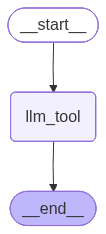

In [18]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
## invocation

messages=graph.invoke({"messages": "what is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (fm7yf177d)
 Call ID: fm7yf177d
  Args:
    a: 2
    b: 2


In [21]:
tools=[add]

In [22]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder=StateGraph(State)

## add nodes
builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## add edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges("llm_tool", tools_condition)
builder.add_edge("tools", END)

graph_builder = builder.compile()

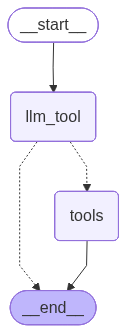

In [24]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [25]:
messages=graph_builder.invoke({"messages": "what is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (pggw4e5wt)
 Call ID: pggw4e5wt
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
